# Titanic dataset

Goal: train a classifier that can predict the Survived column based on the other columns

## Setup

In [62]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

from sklearn.model_selection import train_test_split

## Load Data

In [63]:
def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

## Prepare train and test datasets

This is the Kagle competition. The test_df does not contain the label.
Conclusion: use train_df as full dataset

In [64]:
kaggle_train_df, kaggle_test_df = load_titanic_data()
full_df = kaggle_train_df

In [65]:
X, y = full_df.drop("Survived", axis=1), full_df["Survived"]

In [66]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [68]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [69]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


The label ballance needs to be inspected to decide on what type of split to do:

In [70]:
y.value_counts() / y.count()

,count
Survived,
0,0.616162
1,0.383838


Survived is imbalanced (≈62% died, ≈38% survived) => use a stratified split.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y
    )

In [72]:
y_train.value_counts() / y_train.count()

,count
Survived,
0,0.616573
1,0.383427


In [73]:
y_test.value_counts() / y_test.count()

,count
Survived,
0,0.614525
1,0.385475


## Label EDA


<Axes: >

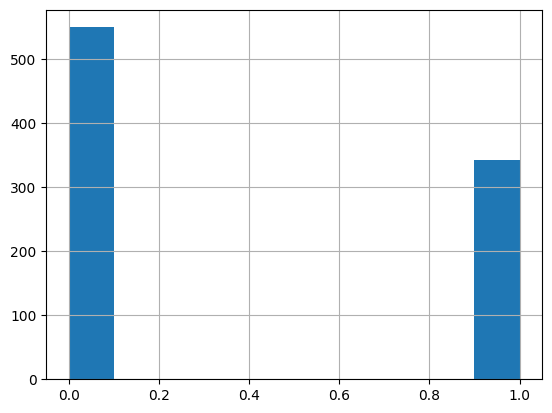

In [57]:
y.hist()

## Features EDA

In [74]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


### "Name"
do not use Name. extract titles and use as categorical feature

In [61]:
X_train.head(30)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
481,482,2,"Frost, Mr. Anthony Wood 'Archie'",male,NaN,0,0,239854,0.0000,NaN,S
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S
652,653,3,"Kalvik, Mr. Johannes Halvorsen",male,21.0,0,0,8475,8.4333,NaN,S
509,510,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
557,558,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.5250,NaN,C
828,829,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
18,19,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S


In [76]:
import re

def extract_title(name):
    match = re.search(r", (.*?)\.", name)
    return match.group(1) if match else ""

X_train["Title"] = X_train["Name"].apply(extract_title)
X_test["Title"]  = X_test["Name"].apply(extract_title)

X_train.drop("Name", axis=1, inplace=True)
X_test.drop("Name", axis=1, inplace=True)


In [77]:
X_train.head(5)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
692,693,3,male,NaN,0,0,1601,56.4958,NaN,S,Mr
481,482,2,male,NaN,0,0,239854,0.0000,NaN,S,Mr
527,528,1,male,NaN,0,0,PC 17483,221.7792,C95,S,Mr
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs


In [80]:
X_train["Title"].value_counts()

,count
Title,
Mr,412
Miss,141
Mrs,107
Master,31
Dr,6
Rev,5
Mlle,2
Col,2
Major,1


In [82]:
rare_titles = ["Dr","Rev","Mlle","Col","Major","Lady","Sir","Ms","Jonkheer","Don"]
X_train["Title"] = X_train["Title"].replace(rare_titles, "Rare")
X_test["Title"]  = X_test["Title"].replace(rare_titles, "Rare")
X_train["Title"].value_counts()

,count
Title,
Mr,412
Miss,141
Mrs,107
Master,31
Rare,21


## "Pclass"
categorical

<Axes: >

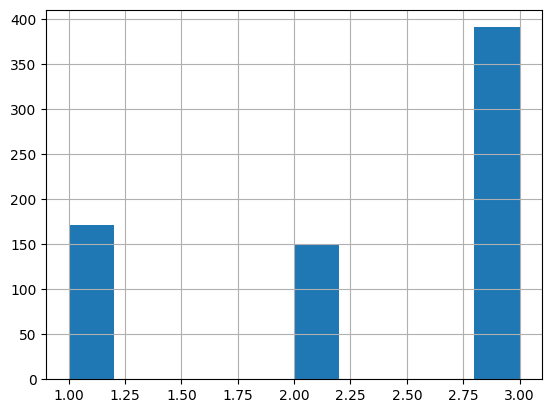

In [84]:
X_train["Pclass"].hist()

In [87]:
X_train["Pclass"].isnull().sum()

np.int64(0)

In [89]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
692,693,3,male,NaN,0,0,1601,56.4958,NaN,S,Mr
481,482,2,male,NaN,0,0,239854,0.0000,NaN,S,Mr
527,528,1,male,NaN,0,0,PC 17483,221.7792,C95,S,Mr
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs


## "Sex"
add Sex as categorical
2/3 of dataset are male

In [90]:
X_train["Sex"].isnull().sum()

np.int64(0)

In [92]:
X_train["Sex"].value_counts()

,count
Sex,
male,459
female,253


## "Age"

<Axes: >

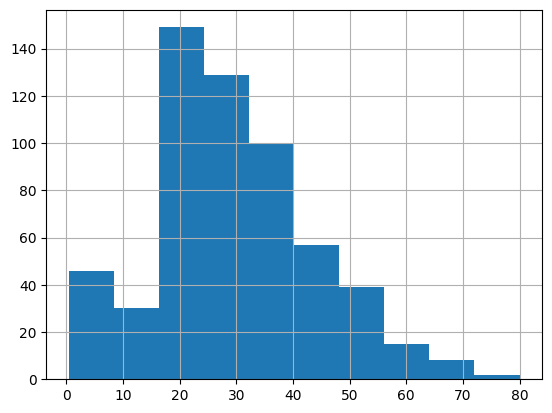

In [93]:
X_train["Age"].hist()

In [97]:
X_train["Age"].isnull().sum()

np.int64(137)

A lot of age features are missing, but it could has strong predictor for survival.
Conclusion:
- add feature "age_missing"
- Impute missing age by median within Title

In [98]:
X_train["Age_missing"] = X_train["Age"].isna().astype(int)
X_test["Age_missing"]  = X_test["Age"].isna().astype(int)

In [99]:
X_train["Age_missing"].value_counts()

,count
Age_missing,
0,575
1,137


In [105]:
from numpy import median

# Impute by median within Title

X_train["Age"] = X_train.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)
X_test["Age"] = X_test.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)

<Axes: >

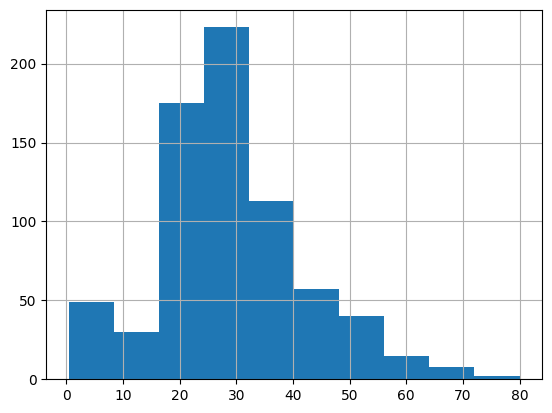

In [106]:
X_train["Age"].hist()

In [107]:
X_train["Age"].isnull().sum()

np.int64(0)

In [108]:
# optional: binning is good for logistic regression
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child","Teen","YoungAdult","Adult","Senior"]

X_train["Age_bin"] = pd.cut(X_train["Age"], bins=bins, labels=labels)
X_test["Age_bin"]  = pd.cut(X_test["Age"], bins=bins, labels=labels)

In [109]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult


## "SibSp" and "Parch"


Examples
Passenger,	Traveling with,	SibSp,	Parch

Single man, alone, 	nobody	0	0

Woman with husband, spouse	1	0

Boy with parents, mom & dad	0	2

Mother with baby, child	0	1

Man with wife + 2 kids	wife + 2 children	1	2

Sisters traveling together	1 sibling	1	0


<Axes: >

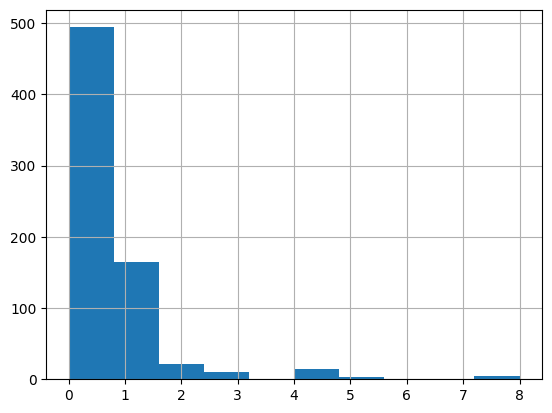

In [111]:
X_train["SibSp"].hist()

In [112]:
X_train["SibSp"].isnull().sum()

np.int64(0)

In [113]:
X_train["SibSp"].value_counts()

,count
SibSp,
0,494
1,164
2,21
4,15
3,10
8,5
5,3


In [114]:
X_train["Parch"].isnull().sum()

np.int64(0)

<Axes: >

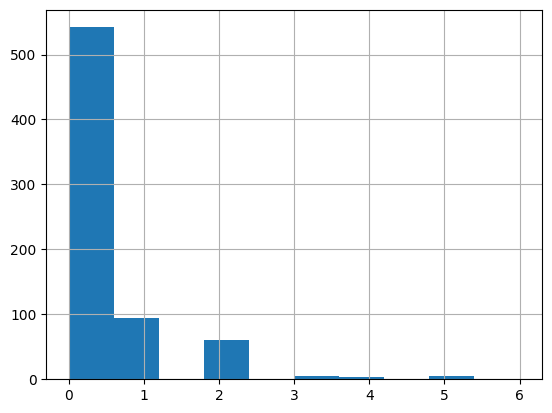

In [115]:
X_train["Parch"].hist()

In [ ]:
# FamilySize = SibSp + Parch + 1
# +1 for the passenger

## Summary

TODO: renamve the file to EDA nad feature engineering

In [110]:
cat_cols = ["Title", "Pclass", "Sex", "Age_missing"]
num_cols = ["Age"]
optional_cat = ["Age_bin"] # for logistic regression